# **Cyclic GAN + cGAN + L1**

Generator with Residual Blocks: Uses a U-Net with residual connections to preserve spatial information and handle deep networks.

Multi-Scale Discriminators: Three discriminators operating at different scales to capture both global structure and fine details.

Feature Matching Loss: Helps stabilize training by matching intermediate features.

Perceptual (VGG) Loss: Ensures generated images are perceptually similar to real ones.

GAN Loss: Standard adversarial loss to make outputs realistic.

L1 Loss: Encourages pixel-wise similarity between generated and real images.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**IMPORT NECESSARY LIBRARIES AND LOAD THE DATA**

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class SketchToImageDataset(Dataset):
    def __init__(self, sketch_dir, image_dir, transform=None):
        self.sketch_dir = sketch_dir
        self.image_dir = image_dir
        self.transform = transform
        self.sketch_files = sorted(os.listdir(sketch_dir))
        self.image_files = sorted(os.listdir(image_dir))


    def __len__(self):
        return len(self.sketch_files)

    def __getitem__(self, idx):
        sketch_path = os.path.join(self.sketch_dir, self.sketch_files[idx])
        image_path = os.path.join(self.image_dir, self.image_files[idx])

        sketch = Image.open(sketch_path).convert('RGB')
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            sketch = self.transform(sketch)
            image = self.transform(image)

        return sketch, image

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = SketchToImageDataset(
    sketch_dir="/content/drive/My Drive/Dataset/ZipDatasets/TrainB",
    image_dir="/content/drive/My Drive/Dataset/ZipDatasets/ValA",
    transform=transform
)

val_dataset = SketchToImageDataset(
    sketch_dir="/content/drive/My Drive/Dataset/ZipDatasets/ValB",
    image_dir="/content/drive/My Drive/Dataset/ZipDatasets/TrainA",
    transform=transform
)
test_dataset = SketchToImageDataset(
    sketch_dir="/content/drive/My Drive/Dataset/ZipDatasets/TestB",
    image_dir="/content/drive/My Drive/Dataset/ZipDatasets/TestA",
    transform=transform
)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

**GENERATOR CODE**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm

class AttentionBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.query = spectral_norm(nn.Conv2d(in_channels, in_channels//8, 1))
        self.key = spectral_norm(nn.Conv2d(in_channels, in_channels//8, 1))
        self.value = spectral_norm(nn.Conv2d(in_channels, in_channels, 1))
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        batch_size, C, H, W = x.shape
        q = self.query(x).view(batch_size, -1, H*W).permute(0, 2, 1)
        k = self.key(x).view(batch_size, -1, H*W)
        v = self.value(x).view(batch_size, -1, H*W)

        attention = F.softmax(torch.bmm(q, k), dim=-1)
        out = torch.bmm(v, attention.permute(0, 2, 1))
        out = out.view(batch_size, C, H, W)
        return self.gamma * out + x

class EnhancedGenerator(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, num_residual=9):
        super().__init__()

        # Initial convolution
        self.conv1 = spectral_norm(nn.Conv2d(input_channels, 64, 7, padding=3))
        self.relu = nn.ReLU()

        # Downsampling
        self.down1 = self._down_block(64, 128)
        self.down2 = self._down_block(128, 256)

        # Residual blocks with attention
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(256) for _ in range(num_residual)],
            AttentionBlock(256)
        )

        # Upsampling
        self.up1 = self._up_block(256, 128)
        self.up2 = self._up_block(128, 64)

        # Output
        self.conv2 = spectral_norm(nn.Conv2d(64, output_channels, 7, padding=3))
        self.tanh = nn.Tanh()

    def _down_block(self, in_c, out_c):
        return nn.Sequential(
            spectral_norm(nn.Conv2d(in_c, out_c, 3, stride=2, padding=1)),
            nn.InstanceNorm2d(out_c),
            nn.ReLU()
        )

    def _up_block(self, in_c, out_c):
        return nn.Sequential(
            spectral_norm(nn.ConvTranspose2d(in_c, out_c, 3, stride=2, padding=1, output_padding=1)),
            nn.InstanceNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.down1(x)
        x = self.down2(x)
        x = self.res_blocks(x)
        x = self.up1(x)
        x = self.up2(x)
        return self.tanh(self.conv2(x))

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
            nn.InstanceNorm2d(channels),
            nn.ReLU(),
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
            nn.InstanceNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)

**MULTISCALE DISCRIMINATOR**

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super(Discriminator, self).__init__()

        # A bunch of convolutions one after another
        model = [
            nn.Conv2d(input_channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        model += [
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        model += [
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        model += [
            nn.Conv2d(256, 512, 4, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        # FCN classification layer
        model += [nn.Conv2d(512, 1, 4, padding=1)]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

In [ ]:
class MultiScaleDiscriminator(nn.Module):
    def __init__(self, input_channels=3, num_discriminators=3):
        super(MultiScaleDiscriminator, self).__init__()

        self.discriminators = nn.ModuleList()

        for _ in range(num_discriminators):
            self.discriminators.append(Discriminator(input_channels))

        self.downsample = nn.AvgPool2d(3, stride=2, padding=1, count_include_pad=False)

    def forward(self, x):
        outputs = []

        for i, discriminator in enumerate(self.discriminators):
            if i > 0:
                x = self.downsample(x)
            outputs.append(discriminator(x))

        return outputs


**TRAINING THE MODEL**

In [ ]:
from torchvision.models import vgg19

class PerceptualLoss(nn.Module):
    def __init__(self, device):
        super().__init__()
        vgg = vgg19(pretrained=True).features[:16].to(device).eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg
        self.criterion = nn.L1Loss()

    def forward(self, fake, real):
        fake_features = self.vgg(fake)
        real_features = self.vgg(real.detach())
        return self.criterion(fake_features, real_features)

def train_model(model, dataloader, device, epochs=100):
    generator = model.generator
    discriminator = model.discriminator

    # Loss functions
    criterion_GAN = torch.nn.MSELoss()
    criterion_pixel = torch.nn.L1Loss()
    criterion_perceptual = PerceptualLoss(device)

    # Optimizers
    opt_g = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

    # Loss weights
    lambda_pixel = 100
    lambda_perceptual = 10

    for epoch in range(epochs):
        for i, (sketches, reals) in enumerate(dataloader):
            sketches = sketches.to(device)
            reals = reals.to(device)

            # Train Discriminator
            with torch.no_grad():
                fakes = generator(sketches)

            # Real images
            pred_real = discriminator(torch.cat([sketches, reals], dim=1))
            loss_real = 0.0
            for pred_r in pred_real:
                loss_real += criterion_GAN(pred_r, torch.ones_like(pred_r))
            loss_real /= len(pred_real)  # Average the loss across scales

            # Fake images
            pred_fake = discriminator(torch.cat([sketches, fakes.detach()], dim=1))
            loss_fake = 0.0
            for pred_f in pred_fake:
                loss_fake += criterion_GAN(pred_f, torch.zeros_like(pred_f))
            loss_fake /= len(pred_fake) # Average the loss across scales

            loss_d = (loss_real + loss_fake) * 0.5
            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()

            # Train Generator
            fakes = generator(sketches)
            pred_fake = discriminator(torch.cat([sketches, fakes], dim=1))

            loss_gan = 0.0
            for pred_f in pred_fake:
                loss_gan += criterion_GAN(pred_f, torch.ones_like(pred_f))
            loss_gan /= len(pred_fake) # Average the loss across scales

            loss_pixel = criterion_pixel(fakes, reals)
            loss_perceptual = criterion_perceptual(fakes, reals)

            loss_g = loss_gan + lambda_pixel * loss_pixel + lambda_perceptual * loss_perceptual
            opt_g.zero_grad()
            loss_g.backward()
            opt_g.step()


            if i % 50 == 0:
                print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(dataloader)}] "
                      f"[D loss: {loss_d.item():.4f}] [G loss: {loss_g.item():.4f}] "
                      f"[Pixel: {loss_pixel.item():.4f}] [Percep: {loss_perceptual.item():.4f}]")

        # Save model checkpoint
        if epoch % 10 == 0:
            torch.save(generator.state_dict(), f"generator_epoch_{epoch}.pth")
            torch.save(discriminator.state_dict(), f"discriminator_epoch_{epoch}.pth")

In [ ]:
import torch
import torch.nn as nn

class ConditionalGAN(nn.Module):
    def __init__(self, device):
        super(ConditionalGAN, self).__init__()
        self.generator = EnhancedGenerator().to(device)
        self.discriminator = MultiScaleDiscriminator(input_channels=6).to(device)

    def forward(self, x):
        return self.generator(x)


**MODEL SUMMARY**

In [ ]:
import torch
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = EnhancedGenerator().to(device)
discriminator = MultiScaleDiscriminator(input_channels=6).to(device)

print("Generator Summary:")
summary(generator, (3, 256, 256))


Generator Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           9,472
              ReLU-2         [-1, 64, 256, 256]               0
            Conv2d-3        [-1, 128, 128, 128]          73,856
    InstanceNorm2d-4        [-1, 128, 128, 128]               0
              ReLU-5        [-1, 128, 128, 128]               0
            Conv2d-6          [-1, 256, 64, 64]         295,168
    InstanceNorm2d-7          [-1, 256, 64, 64]               0
              ReLU-8          [-1, 256, 64, 64]               0
            Conv2d-9          [-1, 256, 64, 64]         590,080
   InstanceNorm2d-10          [-1, 256, 64, 64]               0
             ReLU-11          [-1, 256, 64, 64]               0
           Conv2d-12          [-1, 256, 64, 64]         590,080
   InstanceNorm2d-13          [-1, 256, 64, 64]               0
    ResidualBlock-14

In [ ]:
print("\nDiscriminator Summary (single scale):")
summary(discriminator.discriminators[0], (6, 256, 256)) # Input channels are now 6 (sketch+image)



Discriminator Summary (single scale):
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           6,208
         LeakyReLU-2         [-1, 64, 128, 128]               0
            Conv2d-3          [-1, 128, 64, 64]         131,200
    InstanceNorm2d-4          [-1, 128, 64, 64]               0
         LeakyReLU-5          [-1, 128, 64, 64]               0
            Conv2d-6          [-1, 256, 32, 32]         524,544
    InstanceNorm2d-7          [-1, 256, 32, 32]               0
         LeakyReLU-8          [-1, 256, 32, 32]               0
            Conv2d-9          [-1, 512, 31, 31]       2,097,664
   InstanceNorm2d-10          [-1, 512, 31, 31]               0
        LeakyReLU-11          [-1, 512, 31, 31]               0
           Conv2d-12            [-1, 1, 30, 30]           8,193
Total params: 2,767,809
Trainable params: 2,767,809
Non-trainabl

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConditionalGAN(device)

**TRAINING THE MODEL AT DIFFERENT RESOLUTIONS**

In [ ]:
def progressive_train(model, dataloaders, device, start_size=64, end_size=256):
    current_size = start_size
    while current_size <= end_size:
        print(f"\nTraining at resolution {current_size}x{current_size}")

        # Train at this resolution
        train_model(model, train_loader, device, epochs=50)

        # Increase resolution
        current_size *= 2

progressive_train(model, train_loader, device)


Training at resolution 64x64


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:08<00:00, 68.4MB/s]


[Epoch 0/50] [Batch 0/11] [D loss: 0.6295] [G loss: 74.1918] [Pixel: 0.5837] [Percep: 1.4712]
[Epoch 1/50] [Batch 0/11] [D loss: 0.2713] [G loss: 48.5807] [Pixel: 0.3568] [Percep: 1.2357]
[Epoch 2/50] [Batch 0/11] [D loss: 0.2150] [G loss: 51.7843] [Pixel: 0.3974] [Percep: 1.1558]
[Epoch 3/50] [Batch 0/11] [D loss: 0.1297] [G loss: 49.2342] [Pixel: 0.3776] [Percep: 1.0798]
[Epoch 4/50] [Batch 0/11] [D loss: 0.1818] [G loss: 43.5104] [Pixel: 0.3166] [Percep: 1.1089]
[Epoch 5/50] [Batch 0/11] [D loss: 0.1606] [G loss: 39.5316] [Pixel: 0.2872] [Percep: 1.0022]
[Epoch 6/50] [Batch 0/11] [D loss: 0.1126] [G loss: 48.9162] [Pixel: 0.3739] [Percep: 1.0718]
[Epoch 7/50] [Batch 0/11] [D loss: 0.2942] [G loss: 41.7385] [Pixel: 0.3022] [Percep: 1.0749]
[Epoch 8/50] [Batch 0/11] [D loss: 0.1475] [G loss: 52.3420] [Pixel: 0.4047] [Percep: 1.0843]
[Epoch 9/50] [Batch 0/11] [D loss: 0.0958] [G loss: 44.3930] [Pixel: 0.3325] [Percep: 1.0406]
[Epoch 10/50] [Batch 0/11] [D loss: 0.1390] [G loss: 45.5834

**TESTING AND VISUALIZING THE MODEL**

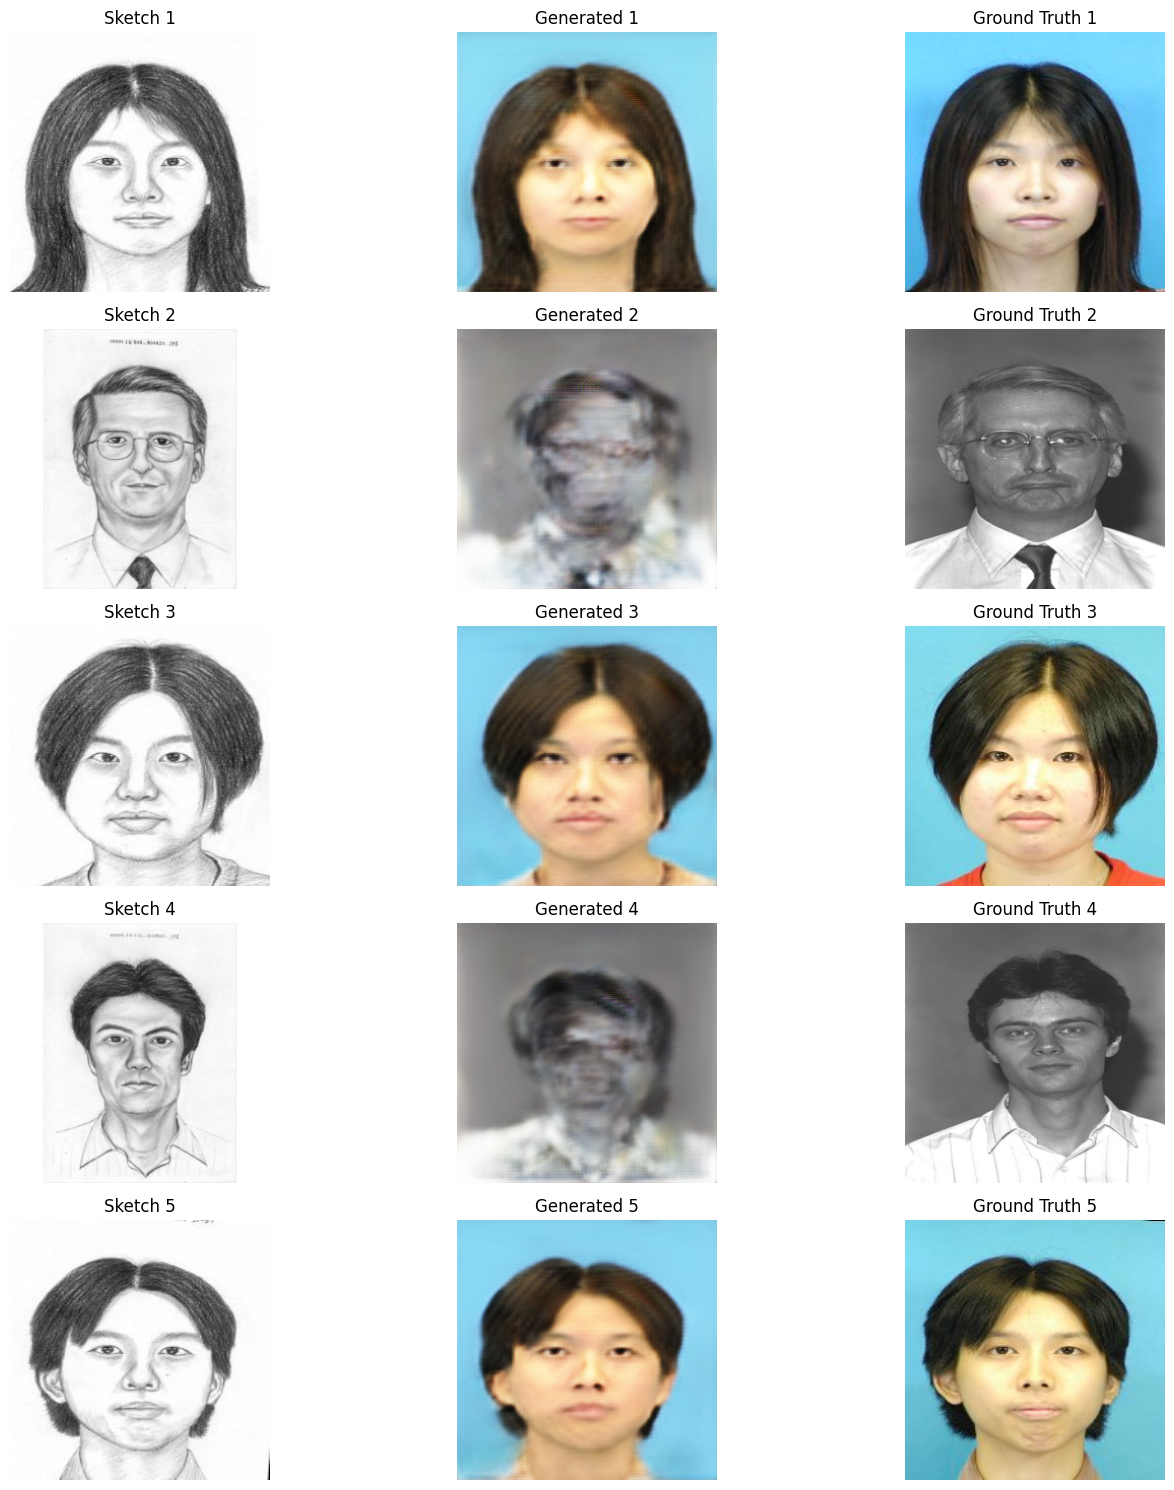

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def test_and_visualize(model, test_loader, device, num_images=5):
    # Set model to evaluation mode
    model.eval()

    # Get the first batch of test data
    sketches, ground_truths = next(iter(test_loader))
    sketches = sketches[:num_images].to(device)
    ground_truths = ground_truths[:num_images].to(device)

    # Generate images
    with torch.no_grad():
        generated_images = model(sketches)

    # Move tensors to CPU and convert to numpy
    sketches = sketches.cpu().numpy()
    generated_images = generated_images.cpu().numpy()
    ground_truths = ground_truths.cpu().numpy()

    # Denormalize images
    def denormalize(img):
        return (img * 0.5) + 0.5

    # Create figure
    plt.figure(figsize=(15, 3*num_images))

    for i in range(num_images):
        # Sketch
        plt.subplot(num_images, 3, i*3 + 1)
        sketch = np.transpose(denormalize(sketches[i]), (1, 2, 0))
        plt.imshow(sketch)
        plt.title(f"Sketch {i+1}")
        plt.axis('off')

        # Generated Image
        plt.subplot(num_images, 3, i*3 + 2)
        gen_img = np.transpose(denormalize(generated_images[i]), (1, 2, 0))
        plt.imshow(gen_img)
        plt.title(f"Generated {i+1}")
        plt.axis('off')

        # Ground Truth
        plt.subplot(num_images, 3, i*3 + 3)
        gt = np.transpose(denormalize(ground_truths[i]), (1, 2, 0))
        plt.imshow(gt)
        plt.title(f"Ground Truth {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# Run the test visualization
test_and_visualize(model, val_loader, device)

**COMPUTING METRICS**

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

def calculate_ssim(model, dataloader, device):
    ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    ssim_values = []

    with torch.no_grad():
        for sketches, real_images in tqdm(dataloader):
            sketches = sketches.to(device)
            real_images = real_images.to(device)

            fake_images = model(sketches)
            fake_images = (fake_images + 1) / 2  # [-1,1] to [0,1]
            real_images = (real_images + 1) / 2

            # Calculate SSIM for each image in the batch and then append to the list
            for fake_img, real_img in zip(fake_images, real_images):
                ssim_value = ssim(fake_img.unsqueeze(0), real_img.unsqueeze(0))
                ssim_values.append(ssim_value.item())  # Get the scalar value from the tensor


    return {
        'mean_ssim': np.mean(ssim_values),
        'std_ssim': np.std(ssim_values)
    }

In [ ]:
from torchmetrics.image import PeakSignalNoiseRatio

def calculate_psnr(model, dataloader, device):
    psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
    psnr_values = []

    with torch.no_grad():
        for sketches, real_images in tqdm(dataloader):
            sketches = sketches.to(device)
            real_images = real_images.to(device)

            fake_images = model(sketches)
            fake_images = (fake_images + 1) / 2  # [-1,1] to [0,1]
            real_images = (real_images + 1) / 2

            # Calculate PSNR for the batch and append the single value
            psnr_value = psnr(fake_images, real_images)
            psnr_values.append(psnr_value.item())  # Get the scalar value

    return {
        'mean_psnr': np.mean(psnr_values),
        'std_psnr': np.std(psnr_values)
    }

In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.6 MB/s eta 0:00:00


In [ ]:
import lpips

def calculate_lpips(model, dataloader, device):
    lpips_model = lpips.LPIPS(net='alex').to(device)
    lpips_values = []

    with torch.no_grad():
        for sketches, real_images in tqdm(dataloader):
            sketches = sketches.to(device)
            real_images = real_images.to(device)

            fake_images = model(sketches)
            fake_images = (fake_images + 1) / 2  # [-1,1] to [0,1]
            real_images = (real_images + 1) / 2

            # LPIPS expects images in [-1,1] range
            dist = lpips_model(fake_images*2-1, real_images*2-1)
            lpips_values.extend(dist.cpu().numpy().flatten())

    return {
        'mean_lpips': np.mean(lpips_values),
        'std_lpips': np.std(lpips_values)
    }

In [ ]:
!pip install tqdm
from tqdm import tqdm


In [ ]:
def evaluate_model(model, val_loader,device):
    print("=== Validation Metrics ===")
    val_ssim = calculate_ssim(model, val_loader, device)
    val_psnr = calculate_psnr(model, val_loader, device)
    val_lpips = calculate_lpips(model, val_loader, device)
    print("\n")
    print(f"\nSSIM: {val_ssim['mean_ssim']:.4f} ± {val_ssim['std_ssim']:.4f}")
    print(f"\nPSNR: {val_psnr['mean_psnr']:.2f} dB ± {val_psnr['std_psnr']:.2f}")
    print(f"\nLPIPS: {val_lpips['mean_lpips']:.4f} ± {val_lpips['std_lpips']:.4f}")

# Run evaluation
evaluate_model(model, val_loader,device)

=== Validation Metrics ===


100%|██████████| 3/3 [00:00<00:00,  3.86it/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 187MB/s]


Loading model from: /usr/local/lib/python3.11/dist-packages/lpips/weights/v0.1/alex.pth


100%|██████████| 3/3 [00:00<00:00,  3.78it/s]




SSIM: 0.6253 ± 0.0982

PSNR: 16.38 dB ± 2.16

LPIPS: 0.3806 ± 0.1953


**SSIM (Structural Similarity Index):**

Range: 0 to 1 (higher is better)

**PSNR (Peak Signal-to-Noise Ratio):**

Typically 20-40 dB (higher is better)

**LPIPS (Learned Perceptual Image Patch Similarity):**

Range: 0 to 1 (lower is better)